# Forecasting con SARIMAX, AutoARIMA y ML
### Mediante modelos de forecasting (SARIMAX, AutoARIMA y Machine Learning) aplicados a datos simulados, se proyecta el tiempo de cobertura de posiciones laborales para las próximas 12 semanas, permitiendo anticipar necesidades y optimizar la planificación.

## Importación de librerías

In [1]:
!pip -q install pmdarima
!pip -q install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.7/415.7 kB 16.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from skforecast.model_selection import grid_search_forecaster, TimeSeriesFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skforecast.recursive import ForecasterRecursive
from pmdarima import auto_arima

## Carga de los datos

In [3]:
df = pd.read_csv("/kaggle/input/datasets/leonardo117/cobertura-rys/dataset_forecasting_vacantes_2022_2025.csv")
print(df.head())

     semana fecha_inicio_semana area  vacantes_abiertas  vacantes_cubiertas  \
0  2022-W01          2022-01-03   IT                 16                  10   
1  2022-W02          2022-01-10   IT                 17                  12   
2  2022-W03          2022-01-17   IT                 16                  13   
3  2022-W04          2022-01-24   IT                 13                  10   
4  2022-W05          2022-01-31   IT                 14                  11   

   tiempo_promedio_cobertura  postulantes_promedio  
0                         34                   111  
1                         28                    80  
2                         32                    70  
3                         29                    99  
4                         29                    61  


## Resumen de los datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   semana                     209 non-null    object
 1   fecha_inicio_semana        209 non-null    object
 2   area                       209 non-null    object
 3   vacantes_abiertas          209 non-null    int64 
 4   vacantes_cubiertas         209 non-null    int64 
 5   tiempo_promedio_cobertura  209 non-null    int64 
 6   postulantes_promedio       209 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.6+ KB


### Convirtiendo los datos a formato fecha

In [5]:
df["fecha_inicio_semana"] = pd.to_datetime(df["fecha_inicio_semana"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   semana                     209 non-null    object        
 1   fecha_inicio_semana        209 non-null    datetime64[ns]
 2   area                       209 non-null    object        
 3   vacantes_abiertas          209 non-null    int64         
 4   vacantes_cubiertas         209 non-null    int64         
 5   tiempo_promedio_cobertura  209 non-null    int64         
 6   postulantes_promedio       209 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 11.6+ KB


### Separando las muestras de entrenamiento y prueba
- **df_train**: muestra de datos que se utilizarán para el entrenamiento.
- **df_test**: muestra de datos que se utilizarán para evaluar el desempeño del modelo.

In [6]:
df_train = df[:-12]
df_test = df[-12:]

## Descomposición de series temporales
- Tendencia
- Estacionalidad
- Residuo

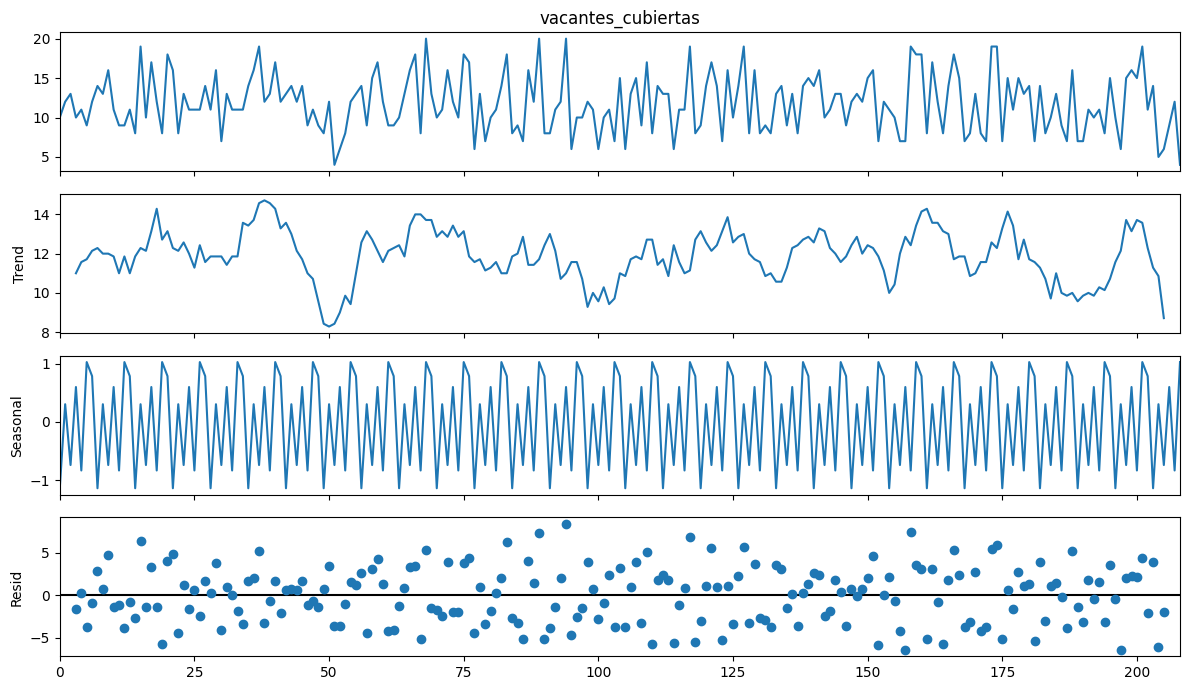

In [7]:
decompose = seasonal_decompose(df["vacantes_cubiertas"], model="additive",
                               period=7)
fig = decompose.plot()
fig.set_size_inches(12, 7)
fig.tight_layout()
fig.savefig("seasonal.jpg")
plt.show()

Se confirma la presencia de estacionalidad, en el gráfico **Seasonal** muestra una regularidad cíclica.

## Verificación de estacionaridad

In [8]:
res_adfuller = adfuller(df_train["vacantes_cubiertas"])
if res_adfuller[1] > 0.05:
    print(f"{res_adfuller[1]}: es una serie no estacionaria")
else:
    print(f"{res_adfuller[1]}: es una serie estacionaria")

1.4872127903637776e-27: es una serie estacionaria


- ### Al obtener un p-value menor a 0.05 en el test de Augmented Dickey-Fuller, se concluye que la serie es estacionaria. Por ello, no fue necesario aplicar diferenciación, estableciendo d=0.

## Análisis ACF y PACF

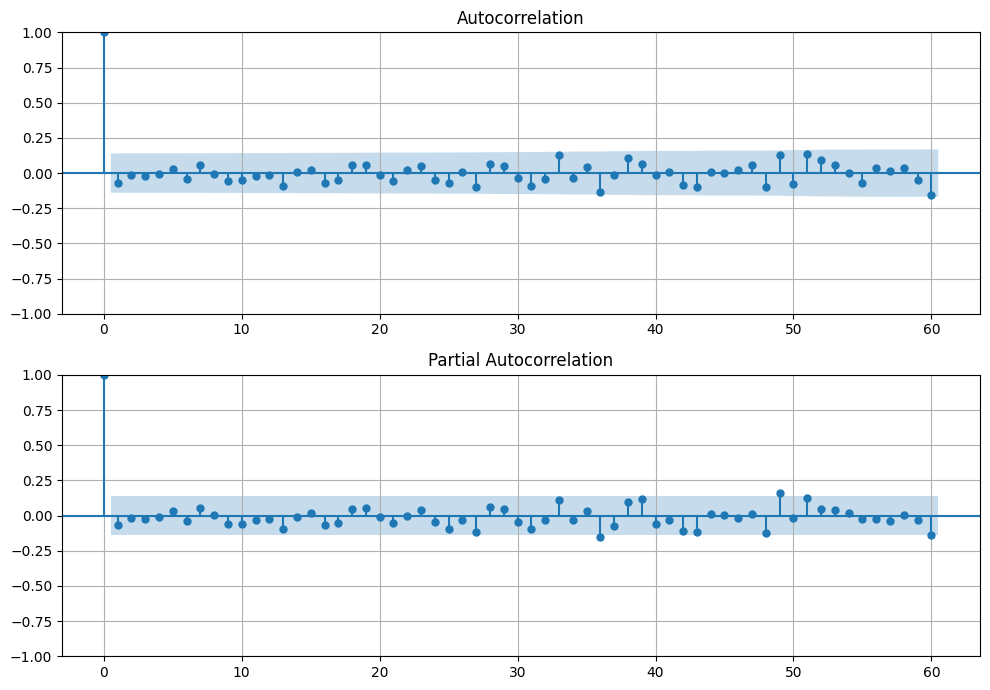

In [9]:
fig, ax = plt.subplots(2,1, figsize=(10,7))
plot_acf(df_train["vacantes_cubiertas"], lags=60, ax=ax[0])
plot_pacf(df_train["vacantes_cubiertas"], lags=60, ax=ax[1])
ax[0].grid(True)
ax[1].grid(True)
plt.tight_layout()
plt.show()

- ### **ACF** y **PACF** siendo métodos de estimación que ayudan a sugerir valores iniciales para **(p,q)** y **(P,Q)** en el modelo SARIMAX.”

## SARIMAX

In [10]:
fr_sarimax = SARIMAX(df_train["vacantes_cubiertas"], exog=df_train[["tiempo_promedio_cobertura","postulantes_promedio"]],
                    order=(1,0,0), seasonal_order=(1,0,1,7))
result_sx = fr_sarimax.fit()
print(result_sx.summary())

                                      SARIMAX Results                                      
Dep. Variable:                  vacantes_cubiertas   No. Observations:                  197
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood                -547.326
Date:                             Thu, 19 Mar 2026   AIC                           1106.652
Time:                                     19:12:01   BIC                           1126.351
Sample:                                          0   HQIC                          1114.626
                                             - 197                                         
Covariance Type:                               opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
tiempo_promedio_cobertura     0.1000      0.026      3.791      0.000       

### Realizando las predicciones con la muestra de prueba

In [11]:
forecast_sx = result_sx.get_forecast(steps=len(df_test), exog=df_test[["tiempo_promedio_cobertura","postulantes_promedio"]])
pred_mean_sx = forecast_sx.predicted_mean
conf_int = forecast_sx.conf_int()

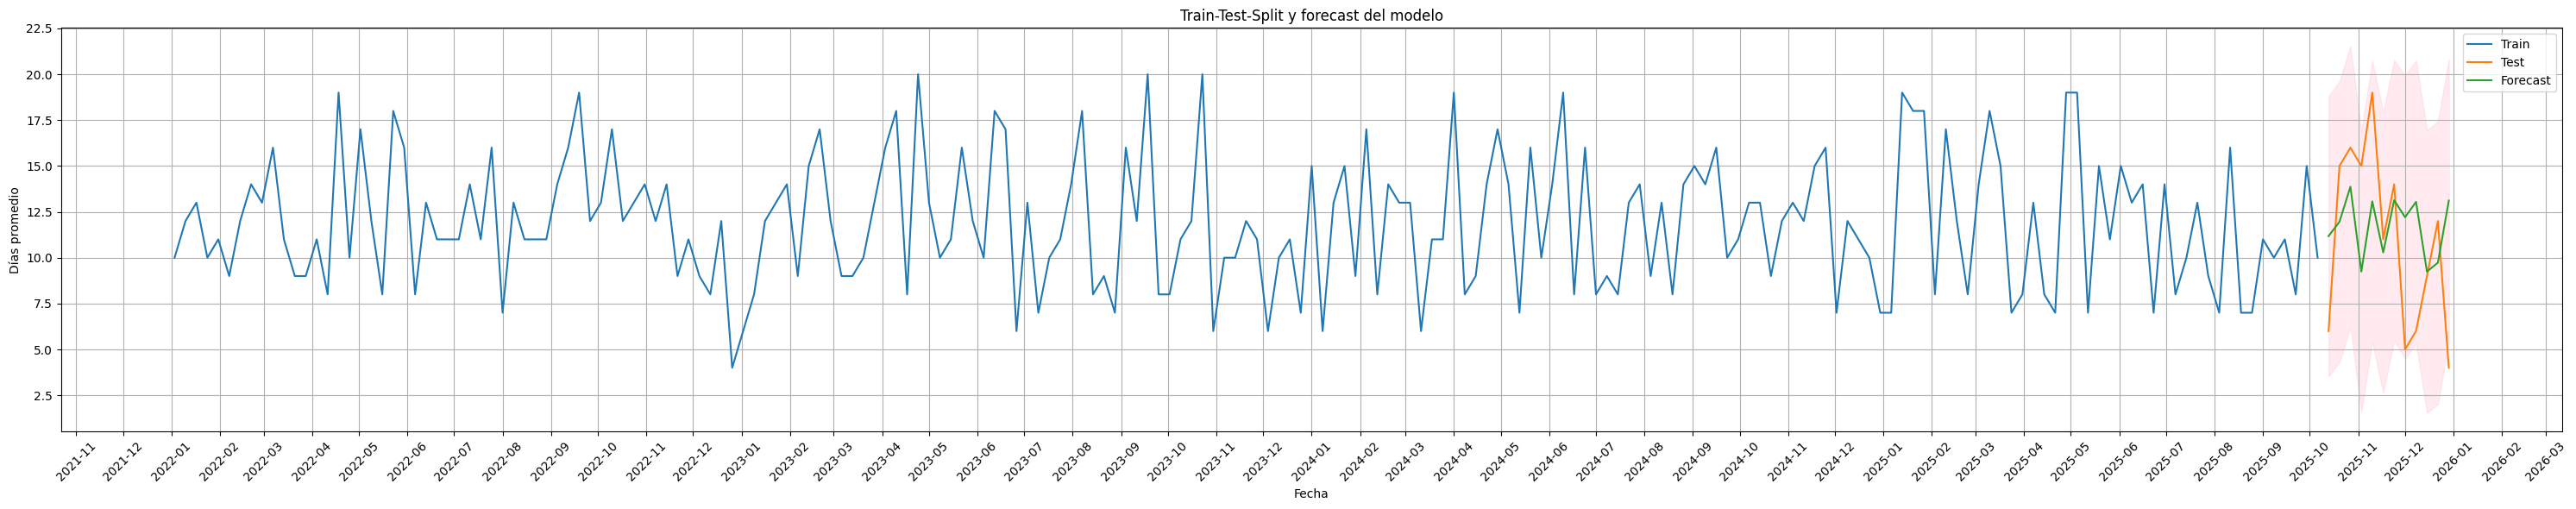

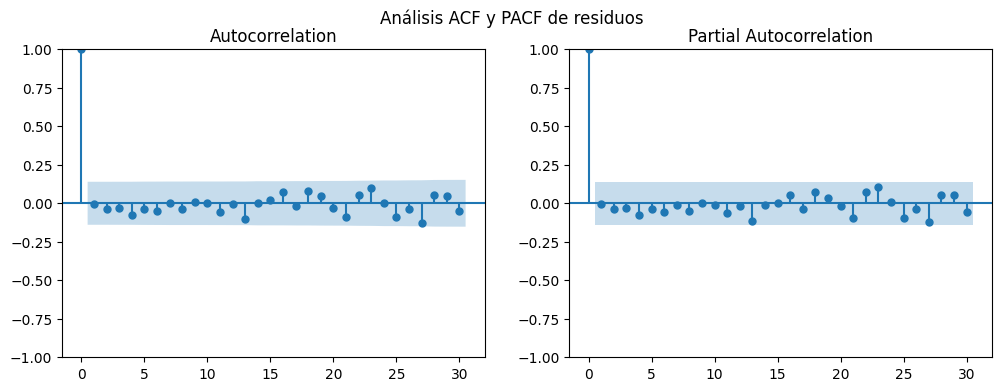

In [12]:
fig, ax = plt.subplots(figsize=(30,6))
ax.plot(df_train["fecha_inicio_semana"], df_train["vacantes_cubiertas"], label="Train")
ax.plot(df_test["fecha_inicio_semana"], df_test["vacantes_cubiertas"], label="Test")
ax.plot(df_test["fecha_inicio_semana"], pred_mean_sx, label="Forecast")
ax.fill_between(df_test["fecha_inicio_semana"], conf_int.iloc[:,0], conf_int.iloc[:,1],
                color="pink", alpha=0.3)
ax.set_title("Train-Test-Split y forecast del modelo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Días promedio")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

residuals = result_sx.resid
resid_std = residuals / np.std(residuals, ddof=1)
fig, ax = plt.subplots(1,2, figsize=(12,4))
fig.suptitle("Análisis ACF y PACF de residuos")
plot_acf(residuals, lags=30, ax=ax[0])
plot_pacf(residuals, lags=30, ax=ax[1])

plt.show()

## Variables exógeneas seleccionadas
### **postulantes_promedio**
- Mientras más postulantes se consiga más rápido será el tiempo de cubrir vacantes; obteniendo así una relación inversa esperada.

### **tiempo_promedio_cobertura**
- Puede evidenciar: eficiencia del proceso o condiciones del mercado laboral; obteniendo un contexto sobre el mercado laboral.

## AUTOARIMA

In [13]:
model_auto = auto_arima(y=df_train["vacantes_cubiertas"],
                        exog=df_train[["tiempo_promedio_cobertura","postulantes_promedio"]],
                        m=7)

In [14]:
fr_auto = SARIMAX(df_train["vacantes_cubiertas"],
                  exog=df_train[["tiempo_promedio_cobertura","postulantes_promedio"]],
                  order=model_auto.order, seasonal_order=model_auto.seasonal_order)
result_auto = fr_auto.fit()
print(result_auto.summary())

                               SARIMAX Results                                
Dep. Variable:     vacantes_cubiertas   No. Observations:                  197
Model:                        SARIMAX   Log Likelihood                -549.326
Date:                Thu, 19 Mar 2026   AIC                           1104.651
Time:                        19:12:05   BIC                           1114.501
Sample:                             0   HQIC                          1108.639
                                - 197                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
tiempo_promedio_cobertura     0.1126      0.026      4.385      0.000       0.062       0.163
postulantes_promedio          0.0952      0.009     10.597      0.000       0.078     

### Realizando las predicciones con la muestra de prueba

In [15]:
forecast_auto = result_auto.get_forecast(steps=len(df_test), exog=df_test[["tiempo_promedio_cobertura","postulantes_promedio"]])
pred_mean_auto = forecast_auto.predicted_mean
conf_int = forecast_auto.conf_int()

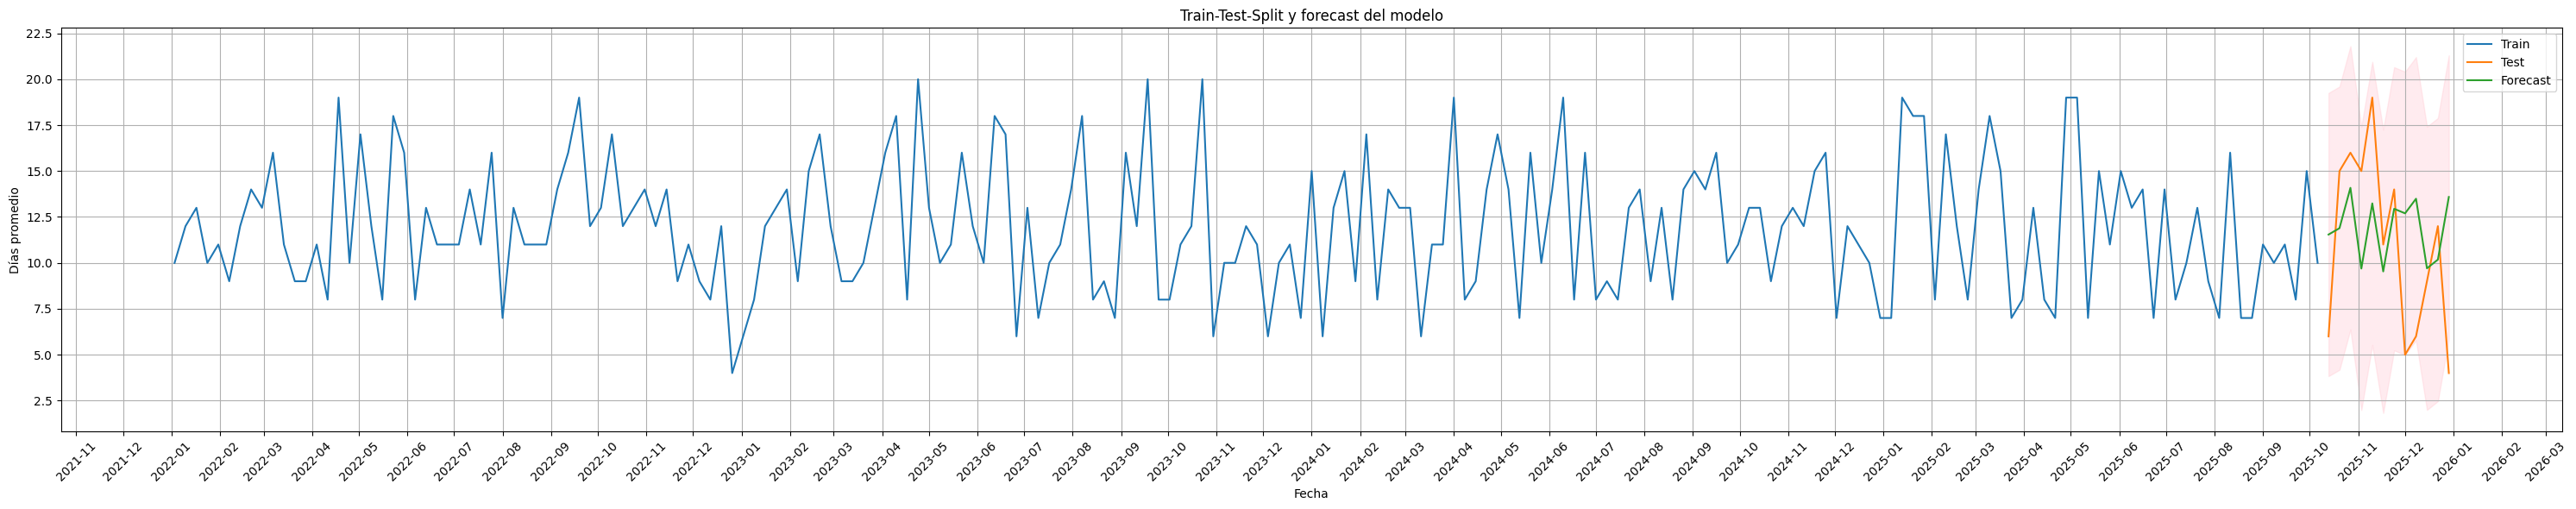

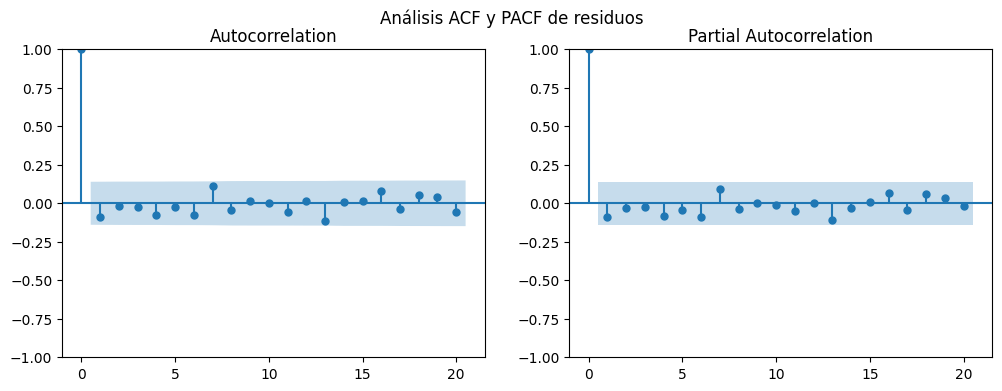

In [16]:
fig, ax = plt.subplots(figsize=(30,6))
ax.plot(df_train["fecha_inicio_semana"], df_train["vacantes_cubiertas"], label="Train")
ax.plot(df_test["fecha_inicio_semana"], df_test["vacantes_cubiertas"], label="Test")
ax.plot(df_test["fecha_inicio_semana"], pred_mean_auto, label="Forecast")
ax.fill_between(df_test["fecha_inicio_semana"], conf_int.iloc[:,0], conf_int.iloc[:,1],
                color="pink", alpha=0.3)
ax.set_title("Train-Test-Split y forecast del modelo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Días promedio")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

residuals = result_auto.resid
resid_std = residuals / np.std(residuals, ddof=1)
fig, ax = plt.subplots(1,2, figsize=(12,4))
fig.suptitle("Análisis ACF y PACF de residuos")
plot_acf(residuals, lags=20, ax=ax[0])
plot_pacf(residuals, lags=20, ax=ax[1])

plt.show()

## ForecasterRecursive - XGBRegressor

In [17]:
model = XGBRegressor(n_estimators=600,learning_rate=0.02,
                     max_depth=4, random_state=42,
                     objective="reg:squarederror")

forecaster = ForecasterRecursive(estimator=model, lags=16, 
                                 differentiation=None)
forecaster.fit(y=df_train["vacantes_cubiertas"],
               exog=df_train[["tiempo_promedio_cobertura","postulantes_promedio"]])

### Realizando las predicciones con la muestra de prueba

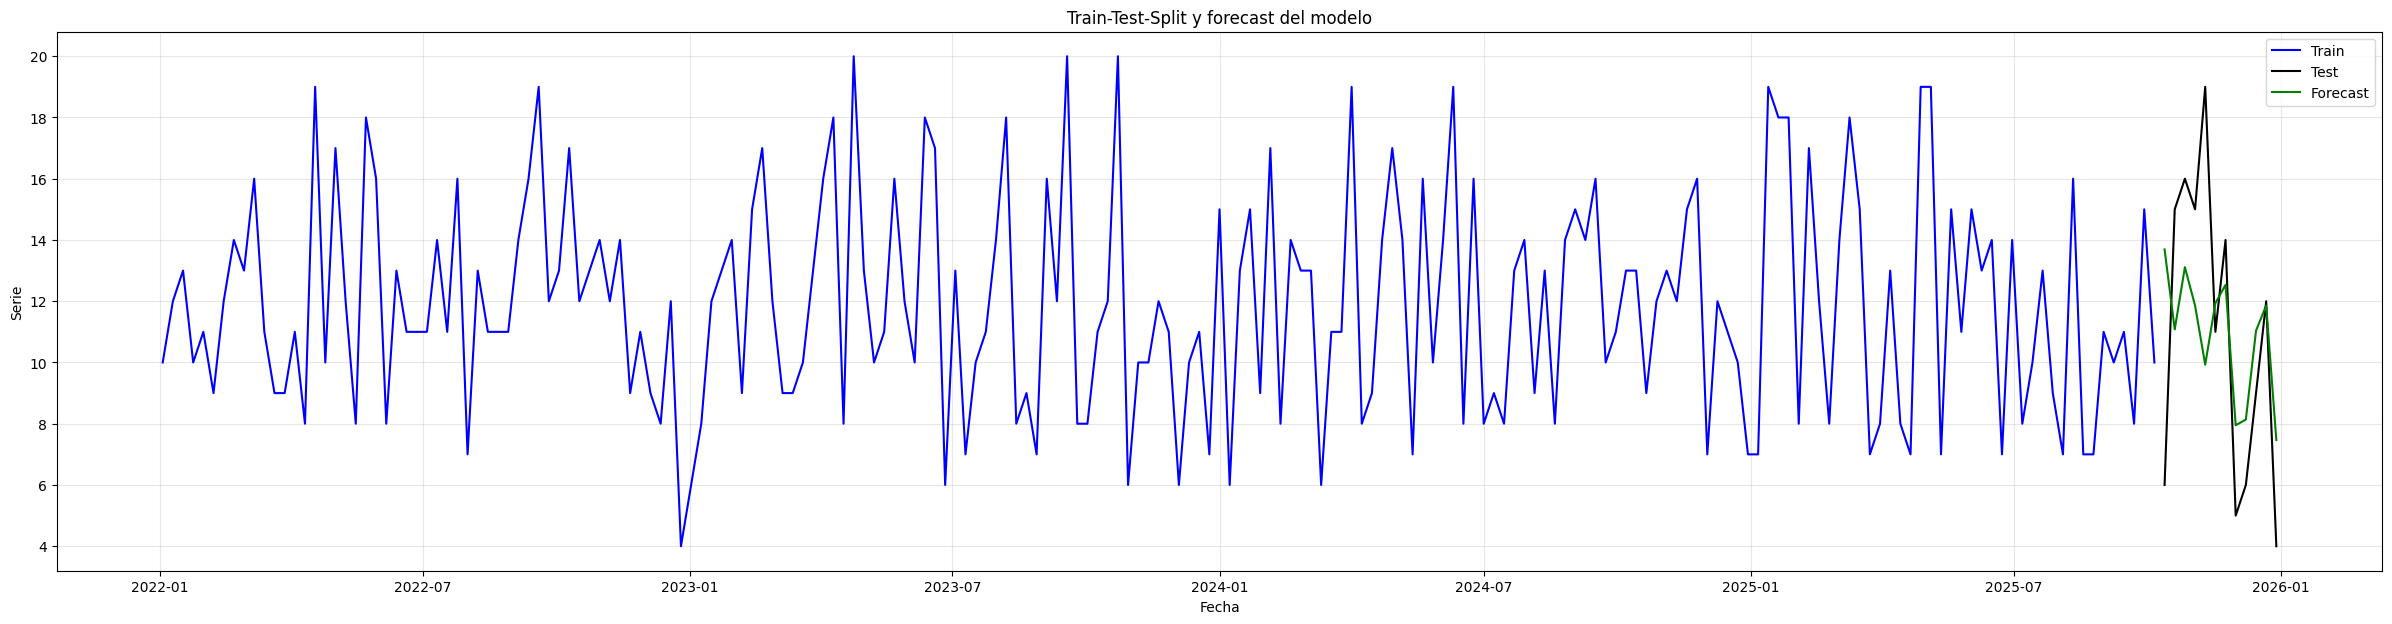

In [18]:
y_pred = forecaster.predict(steps=len(df_test),
                            exog=df_test[["tiempo_promedio_cobertura","postulantes_promedio"]])

fig, ax = plt.subplots(figsize=(30,7))
ax.plot(df_train["fecha_inicio_semana"], df_train["vacantes_cubiertas"],label="Train", color="blue")
ax.plot(df_test["fecha_inicio_semana"], df_test[["vacantes_cubiertas"]], label="Test", color="black")
ax.plot(df_test["fecha_inicio_semana"], y_pred, label="Forecast", color="green")
ax.set_title("Train-Test-Split y forecast del modelo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Serie")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## ForecasterRecursive - RandomForestRegressor

In [19]:
model = RandomForestRegressor(n_estimators=250,
                             criterion="squared_error",
                             max_depth=None)

forecaster_rf = ForecasterRecursive(estimator=model, lags=7, 
                                 differentiation=None)
forecaster_rf.fit(y=df_train["vacantes_cubiertas"],
                  exog=df_train[["tiempo_promedio_cobertura","postulantes_promedio"]])

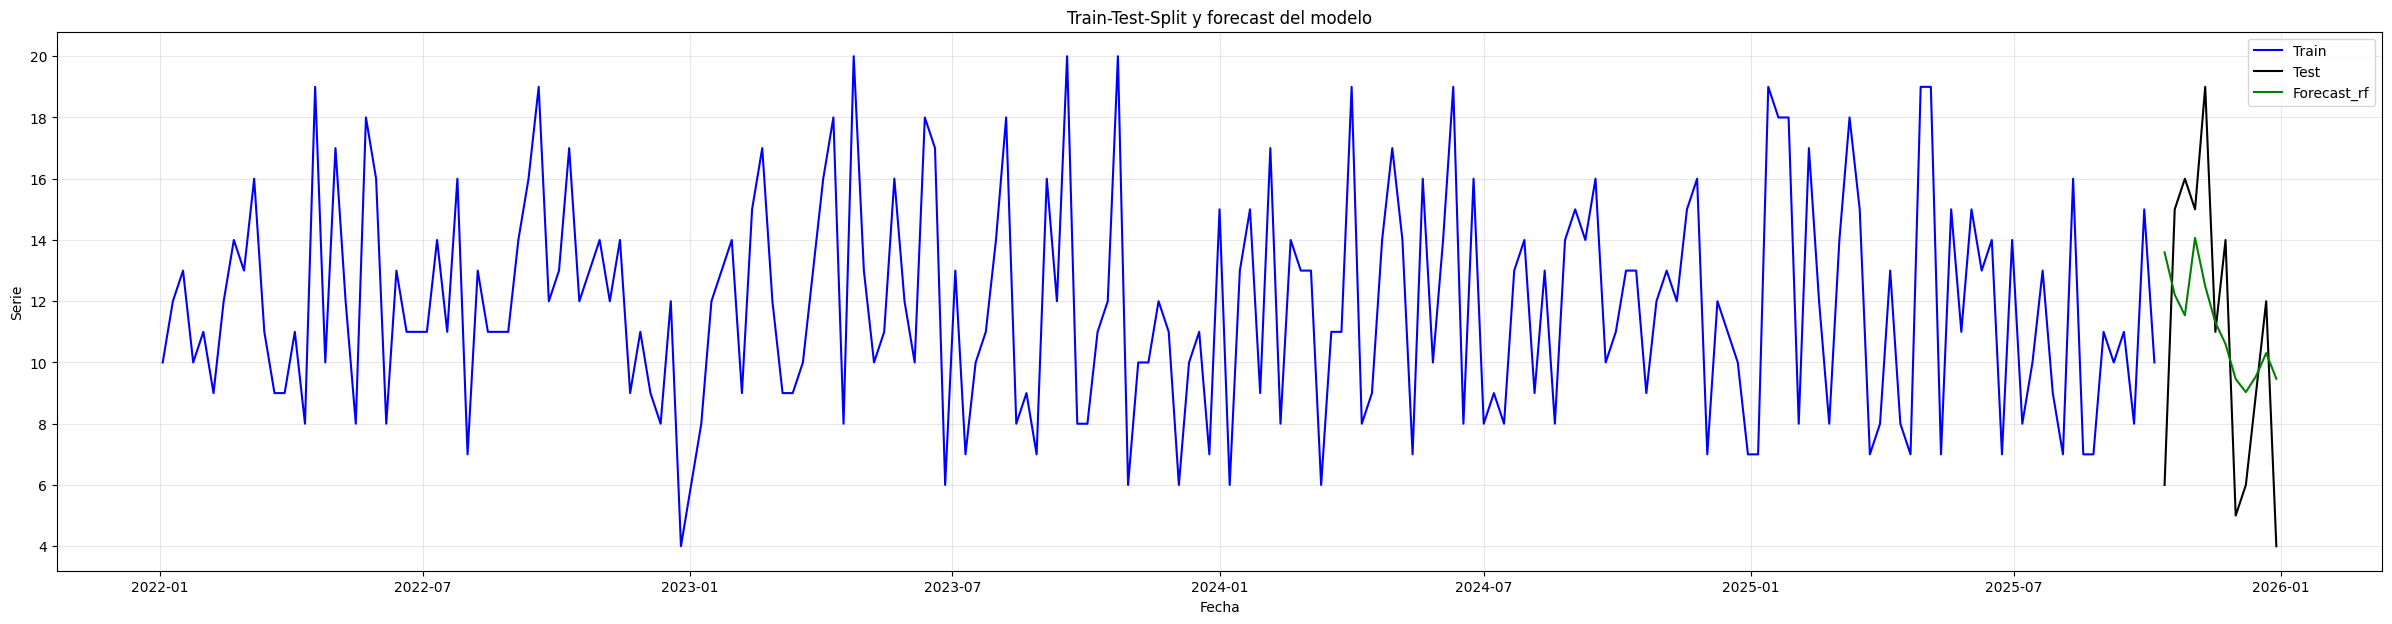

In [20]:
y_pred_rf = forecaster_rf.predict(steps=len(df_test),
                            exog=df_test[["tiempo_promedio_cobertura","postulantes_promedio"]])

fig, ax = plt.subplots(figsize=(30,7))
ax.plot(df_train["fecha_inicio_semana"], df_train["vacantes_cubiertas"],label="Train", color="blue")
ax.plot(df_test["fecha_inicio_semana"], df_test[["vacantes_cubiertas"]], label="Test", color="black")
ax.plot(df_test["fecha_inicio_semana"], y_pred_rf, label="Forecast_rf", color="green")
ax.set_title("Train-Test-Split y forecast del modelo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Serie")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

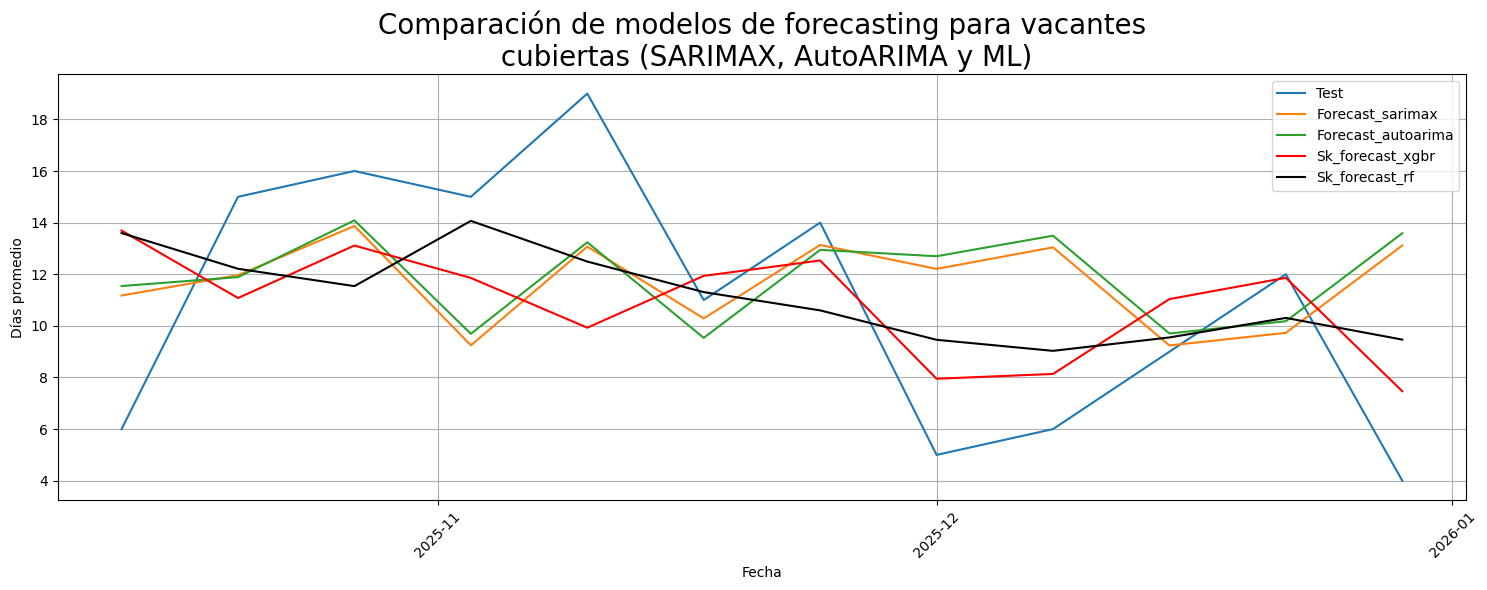

In [21]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15,6))
ax.set_title("Comparación de modelos de forecasting para vacantes\n cubiertas (SARIMAX, AutoARIMA y ML)", size=20)
ax.plot(df_test["fecha_inicio_semana"], df_test["vacantes_cubiertas"], label="Test")
ax.plot(df_test["fecha_inicio_semana"], pred_mean_sx, label="Forecast_sarimax")
ax.plot(df_test["fecha_inicio_semana"], pred_mean_auto, label="Forecast_autoarima")
ax.plot(df_test["fecha_inicio_semana"], y_pred.values, label="Sk_forecast_xgbr", color="red")
ax.plot(df_test["fecha_inicio_semana"], y_pred_rf.values, label="Sk_forecast_rf", color="black")
ax.set_xlabel("Fecha")
ax.set_ylabel("Días promedio")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

## Métricas evaluadas

- ### **MAE (Mean Absolute Error)**
Mide el promedio del error absoluto, expresado en las mismas unidades de la variable objetivo.
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
- $y_i$: valor real
- $\hat{y}_i$: valor predicho
- $n$: número de observaciones

- ### **RMSE (Root Mean Squared Error)**
Aplica la raíz cuadrada del promedio de los errores al cuadrado, penalizando más los errores grandes.

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i|)^2}
$$

- ### **MAPE (Mean Absolute Percentage Error)**
Calcula el error promedio en porcentaje, muy intuitiva.
Muestra problemas cuando en valor real es 0. ($y_i = 0$)

$$
MAPE = \frac{100}{n} \sum_{i=1}^{n} \frac{|y_i - \hat{y}_i|}{y_i}
$$

In [22]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# SARIMAX
mae_sx = mean_absolute_error(df_test["vacantes_cubiertas"], pred_mean_sx.values)
rmse_sx = np.sqrt(mean_squared_error(df_test["vacantes_cubiertas"], pred_mean_sx.values))
mape_val_sx = mape(df_test["vacantes_cubiertas"], pred_mean_sx.values)
# AUTOARIMA
mae_auto = mean_absolute_error(df_test["vacantes_cubiertas"], pred_mean_auto.values)
rmse_auto = np.sqrt(mean_squared_error(df_test["vacantes_cubiertas"], pred_mean_auto.values))
mape_val_auto = mape(df_test["vacantes_cubiertas"], pred_mean_auto.values)
# SK-FORECAST: XGBRegressor
mae_fc = mean_absolute_error(df_test["vacantes_cubiertas"], y_pred.values)
rmse_fc = np.sqrt(mean_squared_error(df_test["vacantes_cubiertas"], y_pred.values))
mape_val_fc = mape(df_test["vacantes_cubiertas"], y_pred.values)
# SK-FORECAST: RandomForestRegressor
mae_rf = mean_absolute_error(df_test["vacantes_cubiertas"], y_pred_rf.values)
rmse_rf = np.sqrt(mean_squared_error(df_test["vacantes_cubiertas"], y_pred_rf.values))
mape_val_rf = mape(df_test["vacantes_cubiertas"], y_pred_rf.values)

metricas = pd.DataFrame({"MAE": [mae_sx, mae_auto, mae_sx, mae_rf],
                         "RMSE": [rmse_sx, rmse_auto, rmse_fc, rmse_rf],
                         "MAPE (%)": [mape_val_sx, mape_val_auto, mape_val_fc, mape_val_rf]},
                        index=["SARIMAX","AUTOARIMA","SK_FORECAST_XGBR","SK_FORECAST_RF"])
metricas.round(2)

,MAE,RMSE,MAPE (%)
SARIMAX,4.12,5.00,59.42
AUTOARIMA,4.29,5.16,62.77
SK_FORECAST_XGBR,4.12,4.16,38.76
SK_FORECAST_RF,3.43,4.11,44.77


## Conclusiones
- ### Tomando en cuenta el menor resultado de los errores tanto como MAE y RMSE se considera el resultado de ForecastRecursive con el modelo RandomForestRegressor, pero considerando que ForecastRecursive con el modelo XGBRegresor registra menos MAPE que en términos porcentuales predice mejor.

- ### Donde el modelo utiliza los últimos 7 semanas (lags) como variables explicativas para realizar la predicción.